## Candle Qubits

#### Imports

In [1]:
## Imports
%load_ext autoreload
%autoreload 2
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, open_docs
from qiskit_metal.qlibrary.qubits.transmon_pocket_6 import TransmonPocket6
from qiskit_metal.qlibrary.qubits.transmon_cross_fl import TransmonCrossFL
from qiskit_metal.qlibrary.couplers.tunable_coupler_01 import TunableCoupler01
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors
from qiskit_metal.qlibrary.lumped.cap_n_interdigital import CapNInterdigital
from qiskit_metal.qlibrary.couplers.cap_n_interdigital_tee import CapNInterdigitalTee
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.launchpad_wb_driven import LaunchpadWirebondDriven
from qiskit_metal.qlibrary.qubits.transmon_cross import TransmonCross

from qiskit_metal.analyses.quantization import EPRanalysis
%matplotlib inline

#### Design

In [2]:

design = metal.designs.DesignPlanar()
gui = metal.MetalGUI(design)

design.overwrite_enabled = True
design.chips.main
design.chips.main.size.size_x = '5mm'
design.chips.main.size.size_y = '5mm'

In [3]:
design.delete_all_components()
# ReadOut Pads & Line
read_pad_1 = LaunchpadWirebondDriven(design, 'ropad_1', options = dict(pos_x = '0mm', pos_y ='0.4mm', orientation = '90'))
read_pad_2 = LaunchpadWirebondDriven(design, 'ropad_2', options = dict(pos_x = '0mm', pos_y ='4.6mm', orientation = '-90'))
bus = RoutePathfinder(design, 'readout_line', options = dict(
    pin_inputs=Dict(
        start_pin=Dict(component='ropad_1', pin='tie'),
        end_pin=Dict(component='ropad_2', pin='tie')),
        total_length = '4.2mm'))

gui.rebuild()
gui.autoscale()

### Qubits

In [4]:
# Create a new Transmon Cross object with name 'Q1'
q1 = TransmonCross(design, 'Q1', options=dict(
    orientation = '270',
    pos_x = '-2mm',
    pos_y = '4mm',
    cross_length = '85um',
    cross_width = '40um',
    connection_pads=dict(
        a = dict( connector_location = '90', connector_type = '0')
    ),))
'''
q2 = TransmonCross(design, 'Q2', options=dict(
    orientation = '90',
    pos_x = '2mm',
    pos_y = '3.5mm',
    cross_length = '75um',
    cross_width = '35um',
    connection_pads=dict(
        a = dict( connector_location = '90', connector_type = '0')
    ),))
'''
gui.rebuild()
gui.autoscale()

### Resonators

In [5]:
## Resonator Calculations
from qiskit_metal.analyses.em.cpw_calculations import guided_wavelength

def find_resonator_length(frequency, line_width, line_gap, N): 
    #frequency in GHz
    #line_width/line_gap in um
    #N -> 2 for lambda/2, 4 for lambda/4
    
    [lambdaG, etfSqrt, q] = guided_wavelength(frequency*10**9, line_width*10**-6,
                                              line_gap*10**-6, 750*10**-6, 200*10**-9)
    return str(lambdaG/N*10**3)+" mm"

#length_1 = find_resonator_length(7.2, 10, 6, 4)
#print(f"Length of resonator 1: {length_1}")

'''Thru calculations:
- Length of resonator 1(7.2): 4.227 mm
- Length of resonator 2(7.1): 4.286 mm
- Length of resonator 3(7.0): 4.347 mm
- Length of resonator 4(6.9): 4.410 mm
- Length of resonator 5(6.8): 4.475 mm
- Length of resonator 6(6.7): 4.542 mm
- Length of coupler: 0.15 mm, gap between two waveguide = 8um to get 10-12k Q-factor
'''

'Thru calculations:\n- Length of resonator 1(7.2): 4.227 mm\n- Length of resonator 2(7.1): 4.286 mm\n- Length of resonator 3(7.0): 4.347 mm\n- Length of resonator 4(6.9): 4.410 mm\n- Length of resonator 5(6.8): 4.475 mm\n- Length of resonator 6(6.7): 4.542 mm\n- Length of coupler: 0.15 mm, gap between two waveguide = 8um to get 10-12k Q-factor\n'

In [6]:
otg1 = OpenToGround(design, 'open_to_ground1', options=dict(pos_x='-30um',  pos_y='4mm', orientation='-90'))
bus1 = RouteMeander(design,'Resonator_1', options = dict(hfss_wire_bonds = True, 
                                            pin_inputs=Dict(
                                                start_pin=Dict(
                                                    component='Q1',
                                                    pin='a'),
                                                end_pin=Dict(
                                                    component='open_to_ground1',
                                                    pin='open')),
                                            lead=Dict(
                                                start_straight='50um',
                                                end_straight = '250um',),
                                            meander=Dict(
                                                asymmetry = '0um'),
                                            fillet = "100um",
                                            total_length = '4.227mm'))
'''
otg2 = OpenToGround(design, 'open_to_ground2', options=dict(pos_x='30um',  pos_y='3.5mm', orientation='-90'))
bus2 = RouteMeander(design,'Resonator_2', options = dict(hfss_wire_bonds = True, 
                                            pin_inputs=Dict(
                                                start_pin=Dict(
                                                    component='Q2',
                                                    pin='a'),
                                                end_pin=Dict(
                                                    component='open_to_ground2',
                                                    pin='open')),
                                            lead=Dict(
                                                start_straight='50um',
                                                end_straight = '250um',),
                                            meander=Dict(
                                                asymmetry = '0um'),
                                            fillet = "100um",
                                            total_length = '4.286mm'))
'''
gui.rebuild()
gui.autoscale()

In [9]:
design.qgeometry.tables['junction']

,component,name,geometry,layer,subtract,helper,chip,width,hfss_inductance,hfss_capacitance,...,hfss_mesh_kw_jj,q3d_inductance,q3d_capacitance,q3d_resistance,q3d_mesh_kw_jj,gds_cell_name,aedt_q3d_inductance,aedt_q3d_capacitance,aedt_hfss_inductance,aedt_hfss_capacitance
0,4,rect_jj,"LINESTRING (-2.08500 4.00000, -2.10500 4.00000)",1,False,False,main,0.04,Lj,Cj,...,0.000007,10nH,0,0,0.000007,my_other_junction,1.000000e-08,0,1.000000e-08,0


In [8]:
qcomps = design.components
qcomps['Q1'].options['hfss_inductance'] = 'Lj'
qcomps['Q1'].options['hfss_capacitance'] = 'Cj'
gui.rebuild()
gui.autoscale()


## 1Xmon Simu

### Old LOM

In [13]:
from qiskit_metal.analyses.quantization import LOManalysis
lom1 = LOManalysis(design,"q3d")

In [14]:
lom1.sim.setup

{'name': 'Setup',
 'reuse_selected_design': True,
 'reuse_setup': True,
 'freq_ghz': 5.0,
 'save_fields': False,
 'enabled': True,
 'max_passes': 15,
 'min_passes': 2,
 'min_converged_passes': 2,
 'percent_error': 0.5,
 'percent_refinement': 30,
 'auto_increase_solution_order': True,
 'solution_order': 'High',
 'solver_type': 'Iterative'}

In [15]:
lom1.sim.setup.name = 'Tune_Q1'
lom1.sim.setup.freq_ghz = 7
lom1.sim.setup.max_passes = 10
lom1.sim.setup.min_converged_passes = 2
lom1.sim.setup.percent_error = 0.5
lom1.sim.setup

{'name': 'Tune_Q1',
 'reuse_selected_design': True,
 'reuse_setup': True,
 'freq_ghz': 7,
 'save_fields': False,
 'enabled': True,
 'max_passes': 10,
 'min_passes': 2,
 'min_converged_passes': 2,
 'percent_error': 0.5,
 'percent_refinement': 30,
 'auto_increase_solution_order': True,
 'solution_order': 'High',
 'solver_type': 'Iterative'}

In [16]:
lom1.sim.run(name="design", components=['Q1', 'Resonator_1', 'ropad_1', 'ropad_2', 'readout_line', 'open_to_ground1'])

INFO 07:37PM [connect_project]: Connecting to Ansys Desktop API...
INFO 07:37PM [load_ansys_project]: 	Opened Ansys App
INFO 07:37PM [load_ansys_project]: 	Opened Ansys Desktop v2025.1.0
INFO 07:37PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/Yi/Documents/Ansoft/
	Project:   Project4
INFO 07:37PM [connect_design]: 	Opened active design
	Design:    design_q3d [Solution type: Q3D]
INFO 07:37PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 07:37PM [connect]: 	Connected to project "Project4" and design "design_q3d" 😀 

INFO 07:37PM [connect_design]: 	Opened active design
	Design:    design_q3d [Solution type: Q3D]
INFO 07:37PM [get_setup]: 	Opened setup `Tune_Q1`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 07:37PM [analyze]: Analyzing setup Tune_Q1
INFO 07:38PM [get_matrix]: Exporting matrix data to (C:\Users\Yi\AppData\Local\Temp\tmpx47l0b28.txt, C, , Tune_Q1:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 7000000000, Maxwell, 1,

In [17]:
lom1.sim.capacitance_matrix

,a_connector_arm_Q1,cross_Q1,g_wb,launch_pad_ropad_1
a_connector_arm_Q1,682.19497,-1.73632,-677.14460,-2.46746
cross_Q1,-1.73632,52.21128,-50.25659,-0.00416
g_wb,-677.14460,-50.25659,1632.21613,-723.15517
launch_pad_ropad_1,-2.46746,-0.00416,-723.15517,727.13888


In [18]:
lom1.setup.junctions = Dict({'Lj': 10, 'Cj': 0})
lom1.setup.freq_readout = 7.2
lom1.setup.freq_bus = []  # list of the bus frequencies

lom1.run_lom()
lom1.lumped_oscillator_all

[1, 2] [3]
Predicted Values

Transmon Properties
f_Q 6.583825 [GHz]
EC 372.540857 [MHz]
EJ 16.339560 [GHz]
alpha -433.106583 [MHz]
dispersion 43.660064 [KHz]
Lq 9.995968 [nH]
Cq 51.994909 [fF]
T1 405.904214 [us]

**Coupling Properties**

tCqbus1 -0.893563 [fF]
gbus1_in_MHz -15.052113 [MHz]
χ_bus1 -0.304612 [MHz]
1/T1bus1 392.099756 [Hz]
T1bus1 405.904214 [us]
Bus-Bus Couplings


,fQ,EC,EJ,alpha,dispersion,gbus,chi_in_MHz,χr MHz,gr MHz
1,7.079807,435.341843,16.33956,-514.465764,168.085036,[-17.030019635004532],[-3.913506563536431],3.913507,17.030020
2,6.887387,410.305061,16.33956,-481.739968,102.000801,[-13.841862703512767],[-0.7443446211358415],0.744345,13.841863
3,6.854383,406.096935,16.33956,-476.277628,93.357134,[-13.07460201752666],[-0.574091386960944],0.574091,13.074602
4,6.723824,389.696004,16.33956,-455.091935,65.20076,[-14.1144075588886],[-0.4098623989565238],0.409862,14.114408
5,6.724,389.717871,16.33956,-455.120072,65.232972,[-14.089507815139342],[-0.4086584033309008],0.408658,14.089508
6,6.722938,389.58605,16.33956,-454.950457,65.03899,[-14.189536107053582],[-0.4130120805208417],0.413012,14.189536
7,6.672511,383.356542,16.33956,-446.946849,56.400015,[-14.436796616794561],[-0.36346048045876406],0.363460,14.436797
8,6.664602,382.384763,16.33956,-445.700433,55.142347,[-14.59436601073114],[-0.3624750070827741],0.362475,14.594366
9,6.599175,374.400163,16.33956,-435.480833,45.661307,[-14.949848421923646],[-0.31369013937724455],0.313690,14.949848
10,6.583825,372.540857,16.33956,-433.106583,43.660064,[-15.052113087413655],[-0.30461194589425095],0.304612,15.052113


In [19]:
lom1.plot_convergence();
lom1.plot_convergence_chi()

Design "design_q3d" info:
	# eigenmodes    0
	# variations    1


INFO 07:38PM [hfss_report_full_convergence]: Creating report for variation 0


In [20]:
lom1.sim.close()

### Eigenmode & EPR

#### Qubit by its own

##### Finite Element Analysis

In [25]:
from qiskit_metal.analyses.quantization import EPRanalysis
eig_qb = EPRanalysis(design, "hfss")
hfss = eig_qb.sim.renderer
hfss.start()
#hfss.clean_active_design()

INFO 11:30PM [connect_project]: Connecting to Ansys Desktop API...
INFO 11:30PM [load_ansys_project]: 	Opened Ansys App
INFO 11:30PM [load_ansys_project]: 	Opened Ansys Desktop v2023.2.0
INFO 11:30PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/WEI-CHEHSU/Documents/Ansoft/
	Project:   Project91
INFO 11:30PM [connect_design]: No active design found (or error getting active design).
INFO 11:30PM [connect]: 	 Connected to project "Project91". No design detected


True

In [26]:
#hfss.activate_ansys_design("Candle", 'eigenmode')
eig_qb.sim.setup.name = 'Tune_Q1'
eig_qb.sim.setup.freq_ghz = 7
eig_qb.sim.setup.min_freq_ghz = 3
eig_qb.sim.setup.max_passes = 12
eig_qb.sim.setup.max_delta_f = 0.1
eig_qb.sim.setup

{'name': 'Tune_Q1',
 'reuse_selected_design': True,
 'reuse_setup': True,
 'min_freq_ghz': 3,
 'n_modes': 1,
 'max_delta_f': 0.1,
 'max_passes': 12,
 'min_passes': 1,
 'min_converged': 1,
 'pct_refinement': 30,
 'basis_order': 1,
 'vars': {'Lj': '10 nH', 'Cj': '0 fF'},
 'freq_ghz': 7}

In [23]:
# add line to build the qubit and resonators

INFO 11:30PM [connect_design]: 	Opened active design
	Design:    Tune_1Q_hfss [Solution type: Eigenmode]
WARNING 11:30PM [connect_setup]: 	No design setup detected.
WARNING 11:30PM [connect_setup]: 	Creating eigenmode default setup.
INFO 11:30PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 11:30PM [get_setup]: 	Opened setup `Tune_Q1`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 11:30PM [analyze]: Analyzing setup Tune_Q1
11:32PM 02s INFO [get_f_convergence]: Saved convergences to c:\Users\WEI-CHEHSU\Desktop\hfss_eig_f_convergence.csv
INFO 11:32PM [__del__]: Disconnected from Ansys HFSS
INFO 11:32PM [__del__]: Disconnected from Ansys HFSS


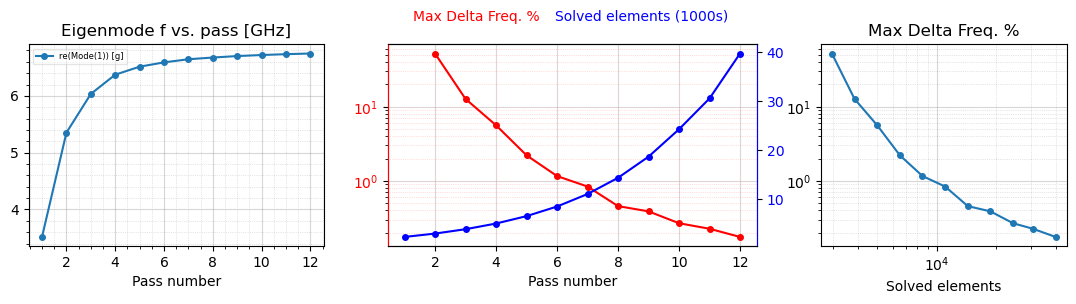

In [27]:
eig_qb.sim.run(name = "Tune_1Q", components=['Q1'], open_terminations=[])
eig_qb.sim.plot_convergences()


In [28]:
eig_qb.sim.convergence_f

,re(Mode(1)) [g]
Pass [],
1,3.516217
2,5.352091
3,6.034056
4,6.373161
5,6.514103
6,6.589708
7,6.644878
8,6.675187
9,6.701044


In [23]:
#eig_qb.sim.plot_fields('main')   # TODO:::: Ez, normal component.....decide which field typically on the qbit, or on the crossing between meanders
#eig_qb.sim.save_screenshot()
# eig_qb.sim.clear_fields()

##### EPR

In [31]:
del eig_qb.setup.junctions['jj']

eig_qb.setup.junctions.jj = Dict(rect='JJ_rect_Lj_Q1_rect_jj', line='JJ_Lj_Q1_rect_jj_',
                  Lj_variable='Lj', Cj_variable='Cj')
eig_qb.setup.sweep_variable = 'Lj'
eig_qb.setup

{'junctions': {'jj': {'rect': 'JJ_rect_Lj_Q1_rect_jj',
   'line': 'JJ_Lj_Q1_rect_jj_',
   'Lj_variable': 'Lj',
   'Cj_variable': 'Cj'}},
 'dissipatives': {'dielectrics_bulk': ['main']},
 'cos_trunc': 8,
 'fock_trunc': 7,
 'sweep_variable': 'Lj'}

Design "Tune_1Q_hfss" info:
	# eigenmodes    1
	# variations    1
Design "Tune_1Q_hfss" info:
	# eigenmodes    1
	# variations    1


  options=pd.Series(get_instance_vars(self.options)),




        energy_elec_all       = 1.21389754553855e-25
        energy_elec_substrate = 1.11847590082806e-25
        EPR of substrate = 92.1%

        energy_mag    = 5.12389711597527e-28
        energy_mag % of energy_elec_all  = 0.4%
        

Variation 0  [1/1]


  Ljs = pd.Series({})

  Cjs = pd.Series({})

  _Om = pd.Series({})




  Mode 0 at 6.75 GHz   [1/1]
    Calculating ℰ_magnetic,ℰ_electric


...

###### Numerical diagonalization

Lj,10
0,6380.87


#### Kerr Non-linear coefficient table (MHz)

###### Numerical diagonalization

,,0
Lj,,
10,0,386.61


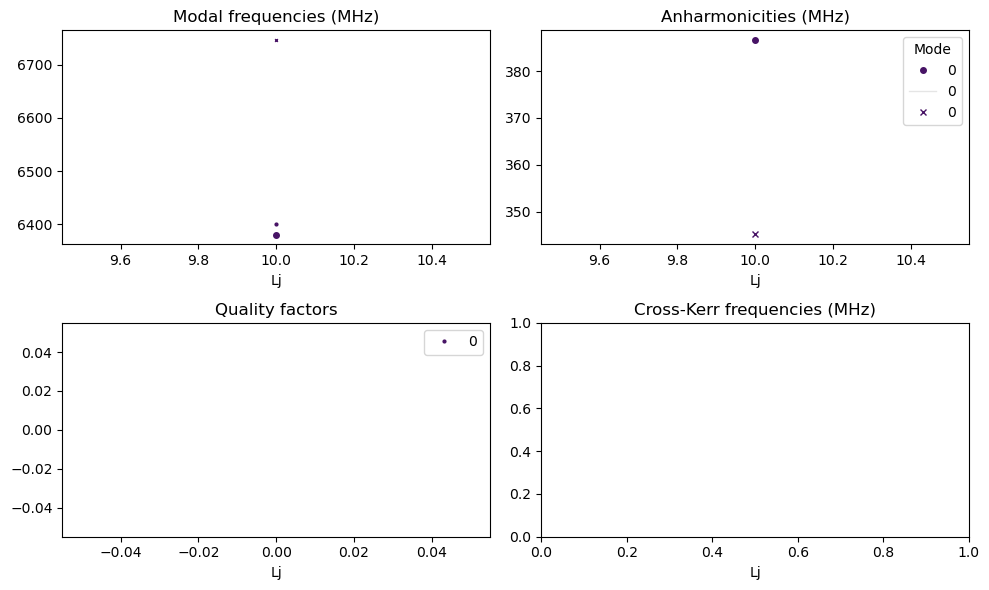

: 

In [ ]:
# eig_qb.sim.renderer.activate_ansys_design('Tune_Q1')
eig_qb.run_epr()



In [ ]:
eig_qb.sim.renderer.pinfo.__dict__

{'project_path': 'C:/Users/Yi/Documents/Ansoft/',
 'project_name': 'hfss',
 'design_name': 'Qbit_hfss',
 'setup_name': 'Tune_Q1',
 'junctions': {'jj': {'Lj_variable': 'Lj',
   'Cj_variable': 'Cj',
   'rect': 'JJ_rect_Lj_Q1_rect_jj',
   'line': 'JJ_Lj_Q1_rect_jj_'}},
 'ports': {},
 'dissipative': {'dielectrics_bulk': ['main'], 'dielectric_surfaces': None, 'resistive_surfaces': None, 'seams': None},
 'options': {'method_calc_P_mj': 'line_voltage', 'save_mesh_stats': True},
 'app': <pyEPR.ansys.HfssApp at 0x1c500c0e250>,
 'desktop': <pyEPR.ansys.HfssDesktop at 0x1c515ae7090>,
 'project': <pyEPR.ansys.HfssProject at 0x1c515ab95d0>,
 'design': <pyEPR.ansys.HfssDesign at 0x1c515af5950>,
 'setup': <pyEPR.ansys.HfssEMSetup at 0x1c51ac4f350>,
 'solution_type': 'Eigenmode'}

#### Resonator by its own